|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Chunked prefill<h1>|
|<h2>Lecture:</h2>|<h1><b>One long prompt stops the whole server<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

/home/venugopalan/vllm-from-scratch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# One long prompt stops the whole server

Thirty-two users are decoding happily, a token every ten milliseconds. Then
somebody pastes in eight thousand tokens.

That prefill has to run. While it runs, nobody else gets a token.

In [2]:
model = AutoModelForCausalLM.from_pretrained(
          'Qwen/Qwen3-0.6B', dtype=torch.bfloat16).cuda().eval()

@torch.inference_mode()
def step_ms(num_tokens):
  """The time of one forward pass with num_tokens tokens in total."""
  token_ids = torch.randint(0, 1000, (1, num_tokens), device='cuda')
  return cudalib.bench_ms(lambda: model(token_ids, use_cache=False, logits_to_keep=1),
                          iters=8, warmup=3, best_of=2)

budgets = [32, 64, 128, 256, 512, 1024, 2048, 4096]
step_times_ms = np.array([step_ms(num_tokens) for num_tokens in budgets])

print(f"{'tokens in the step':>19} {'ms':>8} {'ms per token':>13}")
for num_tokens, time_ms in zip(budgets, step_times_ms):
  print(f'{num_tokens:>19} {time_ms:>8.2f} {time_ms/num_tokens:>13.4f}')

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 12583.11it/s]

 tokens in the step       ms  ms per token
                 32    12.17        0.3804
                 64    12.37        0.1932
                128    12.22        0.0955
                256    15.95        0.0623
                512    26.73        0.0522
               1024    45.41        0.0443
               2048   100.33        0.0490
               4096   250.66        0.0612


### Two regimes in one table

Up to a few hundred tokens, the step costs the same as a step with thirty-two
tokens. You pay to read the weights, and the tokens travel with them at no
cost. This is the memory-bound half of the roofline in Part 1.

After that point the cost becomes linear. You now pay for each token. This is
the compute-bound half.

The scheduler needs the number where the curve bends.

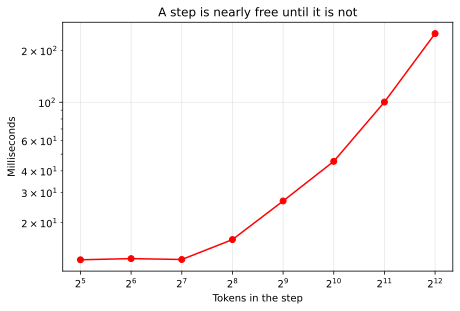

a step is almost free up to approximately 128 tokens


In [3]:
plt.figure(figsize=(7,4.5))
plt.plot(budgets, step_times_ms, 'ro-')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Tokens in the step')
plt.ylabel('Milliseconds')
plt.title('A step is nearly free until it is not')
plt.grid(alpha=.3)
plt.show()

cheap_budgets = [num_tokens for num_tokens, time_ms in zip(budgets, step_times_ms)
                 if time_ms < 1.3*step_times_ms[0]]
print(f'a step is almost free up to approximately {max(cheap_budgets)} tokens')

# What that does to everyone else

Call the decode batch 32 sequences, so a plain decode step holds 32 tokens.
Now put an 8192-token prefill in the same batch.

In [4]:
decode_only = step_ms(32)
stalled = step_ms(4096)     # the largest step that fits with margin

print(f'a normal decode step:        {decode_only:7.2f} ms')
print(f'the step with the prefill:   {stalled:7.2f} ms')
print(f'\nevery one of the 32 users waits {stalled/decode_only:.0f}x longer for that token')

a normal decode step:          15.93 ms
the step with the prefill:    269.00 ms

every one of the 32 users waits 17x longer for that token


### Now chop the prefill up

Nothing says the prefill must finish in one step. Feed it `chunk` tokens at a
time, alongside the decodes, and it takes several steps to complete while
nobody is ever stalled for long.

This is Sarathi-Serve, and it is the throughput/latency dial in every modern
serving stack.

In [5]:
PREFILL = 4096
DECODES = 32

print(f"{'chunk':>7} {'steps to prefill':>17} {'ms per step':>12} {'worst wait':>11}")
rows = []
for chunk in (128, 256, 512, 1024, 2048, 4096):
  per_step = step_ms(DECODES + chunk)
  num_steps = int(np.ceil(PREFILL/chunk))
  rows.append((chunk, num_steps, per_step))
  print(f'{chunk:>7} {num_steps:>17} {per_step:>11.2f}ms {per_step:>10.2f}ms')

  chunk  steps to prefill  ms per step  worst wait


    128                32       14.46ms      14.46ms


    256                16       19.98ms      19.98ms


    512                 8       30.13ms      30.13ms


   1024                 4       57.81ms      57.81ms


   2048                 2      131.30ms     131.30ms


   4096                 1      278.93ms     278.93ms


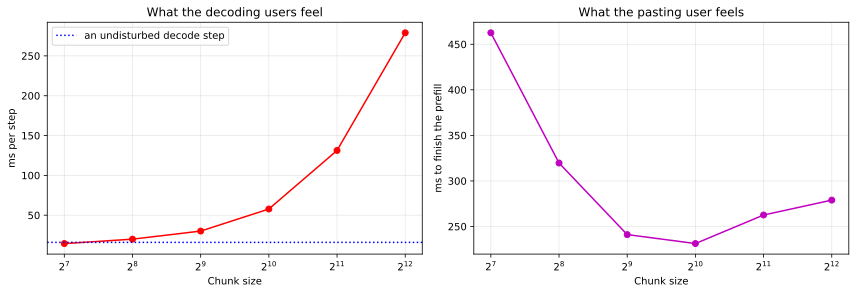

In [6]:
results = np.array(rows, dtype=float)
prefill_ms = results[:,1] * results[:,2]   # steps x time for each step

fig, axes = plt.subplots(1,2, figsize=(12,4.2))
axes[0].plot(results[:,0], results[:,2], 'ro-')
axes[0].axhline(decode_only, color='b', ls=':', label='an undisturbed decode step')
axes[0].set_xscale('log', base=2)
axes[0].set(xlabel='Chunk size', ylabel='ms per step',
           title='What the decoding users feel')
axes[0].legend()
axes[0].grid(alpha=.3)

axes[1].plot(results[:,0], prefill_ms, 'mo-')
axes[1].set_xscale('log', base=2)
axes[1].set(xlabel='Chunk size', ylabel='ms to finish the prefill',
           title='What the pasting user feels')
axes[1].grid(alpha=.3)
plt.tight_layout()
plt.show()

In [7]:
print(f"{'chunk':>7} {'ITL for the 32':>15} {'TTFT for the 1':>15}")
for (chunk, num_steps, per_step), total_ms in zip(rows, prefill_ms):
  print(f'{chunk:>7} {per_step:>14.1f}ms {total_ms:>14.1f}ms')
print(f'\nunchunked, the 32 wait {stalled:.0f} ms for one token.')
print(f'at chunk 256 they wait {rows[1][2]:.0f} ms, and the prefill takes '
      f'{prefill_ms[1]/prefill_ms[-1]:.1f}x longer to finish.')

  chunk  ITL for the 32  TTFT for the 1
    128           14.5ms          462.6ms
    256           20.0ms          319.6ms
    512           30.1ms          241.1ms
   1024           57.8ms          231.2ms
   2048          131.3ms          262.6ms
   4096          278.9ms          278.9ms

unchunked, the 32 wait 269 ms for one token.
at chunk 256 they wait 20 ms, and the prefill takes 1.1x longer to finish.


### The dial, stated plainly

- **Small chunks**: the users who decode almost do not see the prefill. The
  long prompt needs more time to start. Each step carries less of it, and each
  step still pays to read the weights.
- **Large chunks**: the prefill finishes as fast as the hardware permits, and
  every other user feels it.

No setting is the best for both, so a real engine makes this value a
configuration knob. It does not choose for you.

You can still refuse to make a stupid choice. The left half of the first plot
showed that a step is almost free up to a few hundred tokens. A chunk below
that size buys latency that you were not going to feel. It costs throughput
that you were going to feel.

The modern form of this idea goes further. vLLM V1 removed the difference
between a prefill step and a decode step. Each step has a **token budget**. A
request contributes as many tokens as it needs. The token can be one
continuation token or a slice of a prompt.

    ./vc guide 11